# Workshop: Using PCA to Simplify Datasets

---

## Welcome to the PCA Workshop!

In this workshop, you will learn how to use **Principal Component Analysis (PCA)** to:

- Reduce the number of features in your data
- Visualize high-dimensional data in 2D
- Speed up machine learning models

---

## Real-World Applications:

- **Netflix**: Reduces user rating dimensions for faster recommendations
- **Spotify**: Simplifies audio features for music similarity
- **Face Recognition**: Reduces image pixels to key features
- **Medical Research**: Finds patterns in gene data

---

## Instructions:

**Run each cell one by one** by pressing **Shift + Enter**

Read the explanations to understand what each step does!

---

# STEP 1: Import Libraries

We need several tools:
- **pandas** for data handling
- **numpy** for math operations
- **sklearn** for PCA and sample datasets
- **matplotlib** for charts

In [3]:
# Import pandas for working with data tables
import pandas as pd
print("✓ pandas loaded!")

✓ pandas loaded!


In [4]:
# Import numpy for math operations
import numpy as np
print("✓ numpy loaded!")

✓ numpy loaded!


In [5]:
# Import PCA from sklearn
from sklearn.decomposition import PCA
print("✓ PCA loaded!")

✓ PCA loaded!


In [6]:
# Import StandardScaler for data preparation
# PCA works better when data is scaled
from sklearn.preprocessing import StandardScaler
print("✓ StandardScaler loaded!")

✓ StandardScaler loaded!


In [7]:
# Import the famous Iris dataset
# This has 4 features of flower measurements
from sklearn.datasets import load_iris
print("✓ Iris dataset loaded!")

✓ Iris dataset loaded!


In [8]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt
print("✓ matplotlib loaded!")

✓ matplotlib loaded!


In [9]:
print("="*50)
print("ALL LIBRARIES READY!")
print("="*50)

ALL LIBRARIES READY!


---

# STEP 2: Load and Explore the Iris Dataset

The **Iris dataset** is a classic ML dataset with:
- 150 flower samples
- 4 features: sepal length, sepal width, petal length, petal width
- 3 species: Setosa, Versicolor, Virginica

Our goal: Reduce 4 features to 2 for visualization!

In [11]:
# Load the Iris dataset
iris = load_iris()
print("Iris dataset loaded!")
print(f"Type: {type(iris)}")

Iris dataset loaded!
Type: <class 'sklearn.utils._bunch.Bunch'>


In [12]:
# Get the feature data (X) and labels (y)
X = iris.data
y = iris.target

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Features shape: (150, 4)
Labels shape: (150,)


In [13]:
# What are the feature names?
feature_names = iris.feature_names
print("Feature names:")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")

Feature names:
  1. sepal length (cm)
  2. sepal width (cm)
  3. petal length (cm)
  4. petal width (cm)


In [14]:
# What are the species names?
species_names = iris.target_names
print("Species names:")
for i, name in enumerate(species_names):
    print(f"  {i}. {name}")

Species names:
  0. setosa
  1. versicolor
  2. virginica


In [15]:
# Convert to DataFrame for easier viewing
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("First 10 rows:")
df.head(10)

First 10 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [16]:
# Summary statistics
print("Statistical summary:")
df.describe()

Statistical summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [17]:
# Count samples per species
print("Samples per species:")
print(df['species_name'].value_counts())

Samples per species:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


---

# STEP 3: The Problem - Visualizing 4D Data

We have 4 features. How do we visualize 4 dimensions?

We can only plot 2 features at a time, which means we miss the full picture!

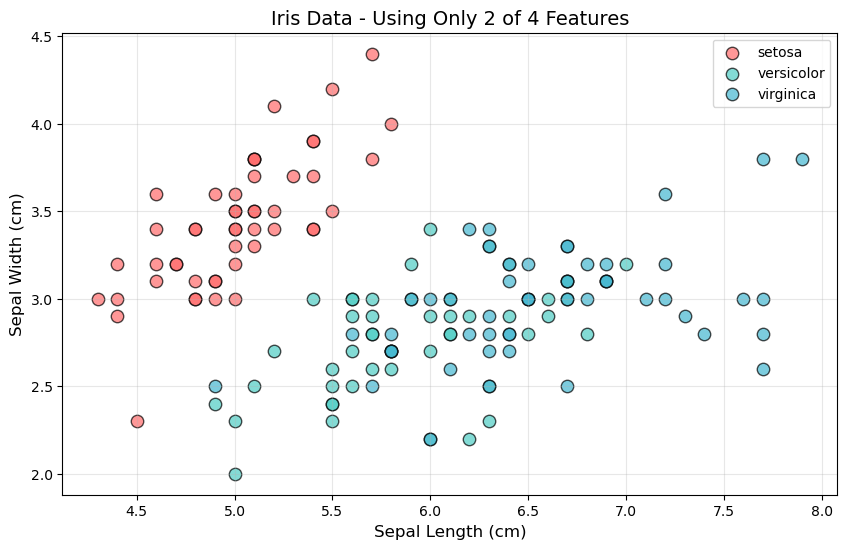


Notice: Species overlap! We are missing information from petal features.


In [19]:
# Plot just 2 of the 4 features
# This shows only PART of the data!

plt.figure(figsize=(10, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for species_id in [0, 1, 2]:
    mask = y == species_id
    plt.scatter(
        X[mask, 0],  # sepal length
        X[mask, 1],  # sepal width
        c=colors[species_id],
        label=species_names[species_id],
        s=80,
        alpha=0.7,
        edgecolors='black'
    )

plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.title('Iris Data - Using Only 2 of 4 Features', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nNotice: Species overlap! We are missing information from petal features.")

---

# STEP 4: Prepare Data for PCA

Before applying PCA, we should **scale** the data.

**Why scale?**
- PCA looks for maximum variance
- If one feature has large numbers (like 1000) and another has small numbers (like 1), PCA will focus on the big one
- Scaling makes all features equally important

In [21]:
# Create a scaler object
scaler = StandardScaler()
print("Scaler created!")

Scaler created!


In [22]:
# Scale the features
# This makes mean=0 and std=1 for each feature
X_scaled = scaler.fit_transform(X)

print("Data scaled!")
print(f"Shape: {X_scaled.shape}")

Data scaled!
Shape: (150, 4)


In [23]:
# Let's verify the scaling worked
print("BEFORE scaling (first feature):")
print(f"  Mean: {X[:, 0].mean():.2f}")
print(f"  Std:  {X[:, 0].std():.2f}")

print("\nAFTER scaling (first feature):")
print(f"  Mean: {X_scaled[:, 0].mean():.6f} (approximately 0)")
print(f"  Std:  {X_scaled[:, 0].std():.2f}")

BEFORE scaling (first feature):
  Mean: 5.84
  Std:  0.83

AFTER scaling (first feature):
  Mean: -0.000000 (approximately 0)
  Std:  1.00


---

# STEP 5: Apply PCA - Find All Components

First, let's see how much variance each component captures.

We'll fit PCA with ALL 4 components to see the full picture.

In [27]:
# Create PCA with all components
pca_full = PCA(n_components=4)
print("PCA object created (4 components)")

PCA object created (4 components)


In [28]:
# Fit PCA to the scaled data
pca_full.fit(X_scaled)
print("PCA fitted to data!")

PCA fitted to data!


In [29]:
# Get explained variance ratio for each component
explained_variance = pca_full.explained_variance_ratio_

print("Explained Variance by Component:")
print("="*40)
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var*100:.2f}%")

Explained Variance by Component:
PC1: 72.96%
PC2: 22.85%
PC3: 3.67%
PC4: 0.52%


In [30]:
# Calculate cumulative variance
cumulative_variance = np.cumsum(explained_variance)

print("Cumulative Explained Variance:")
print("="*40)
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var*100:.2f}%")

Cumulative Explained Variance:
PC1 to PC1: 72.96%
PC1 to PC2: 95.81%
PC1 to PC3: 99.48%
PC1 to PC4: 100.00%


In [31]:
# Key insight!
print("\n" + "="*50)
print("KEY INSIGHT")
print("="*50)
print(f"\nPC1 + PC2 capture {cumulative_variance[1]*100:.1f}% of the information!")
print(f"\nThis means we can reduce 4 features to 2 features")
print(f"and keep {cumulative_variance[1]*100:.1f}% of what matters!")


KEY INSIGHT

PC1 + PC2 capture 95.8% of the information!

This means we can reduce 4 features to 2 features
and keep 95.8% of what matters!


---

# STEP 6: Visualize Explained Variance

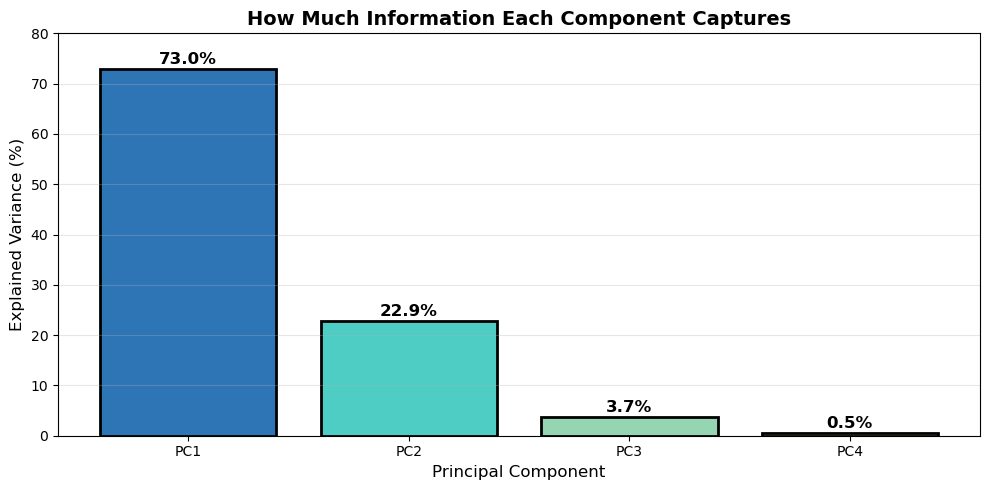

PC1 captures the most variance - it's the most important!


In [33]:
# Create a bar chart of explained variance
plt.figure(figsize=(10, 5))

components = ['PC1', 'PC2', 'PC3', 'PC4']
colors_bar = ['#2E75B6', '#4ECDC4', '#95D5B2', '#D4E6B5']

bars = plt.bar(components, explained_variance * 100, color=colors_bar, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, val in zip(bars, explained_variance * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance (%)', fontsize=12)
plt.title('How Much Information Each Component Captures', fontsize=14, fontweight='bold')
plt.ylim(0, 80)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("PC1 captures the most variance - it's the most important!")

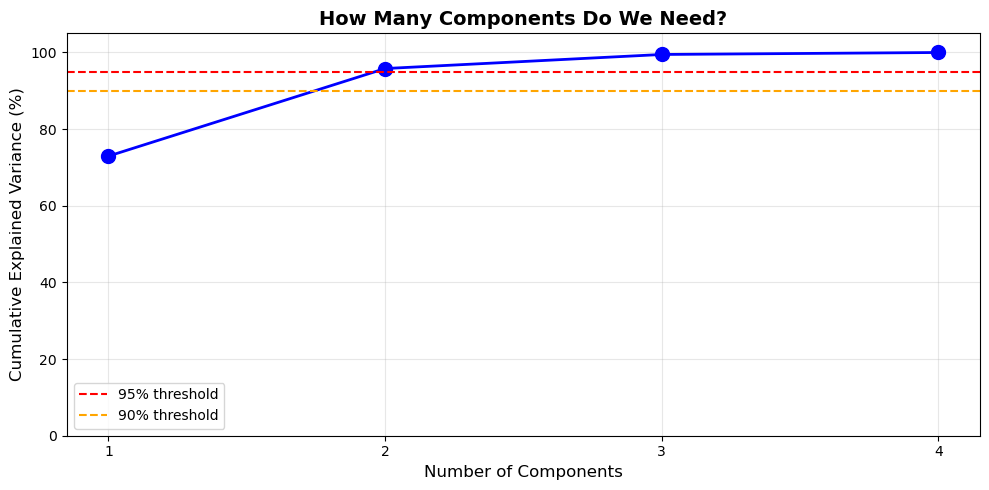


2 components gives us 95%+ variance - that's enough!


In [36]:
# Cumulative variance plot (Scree plot)
plt.figure(figsize=(10, 5))

plt.plot(range(1, 5), cumulative_variance * 100, 'bo-', linewidth=2, markersize=10)
plt.axhline(y=95, color='red', linestyle='--', label='95% threshold')
plt.axhline(y=90, color='orange', linestyle='--', label='90% threshold')

plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance (%)', fontsize=12)
plt.title('How Many Components Do We Need?', fontsize=14, fontweight='bold')
plt.xticks([1, 2, 3, 4])
plt.ylim(0, 105)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n2 components gives us 95%+ variance - that's enough!")

---

# STEP 7: Apply PCA - Reduce to 2 Dimensions

Now let's actually reduce 4 features to 2!

In [39]:
# Create PCA with 2 components
pca_2d = PCA(n_components=2)
print("PCA object created (2 components)")

PCA object created (2 components)


In [40]:
# Transform the data
X_pca = pca_2d.fit_transform(X_scaled)

print(f"Original shape: {X_scaled.shape} (150 samples × 4 features)")
print(f"New shape:      {X_pca.shape} (150 samples × 2 features)")

Original shape: (150, 4) (150 samples × 4 features)
New shape:      (150, 2) (150 samples × 2 features)


In [41]:
# Let's look at the transformed data
print("First 5 samples in new PC space:")
print("="*40)
for i in range(5):
    print(f"Sample {i+1}: PC1={X_pca[i,0]:.3f}, PC2={X_pca[i,1]:.3f}")

First 5 samples in new PC space:
Sample 1: PC1=-2.265, PC2=0.480
Sample 2: PC1=-2.081, PC2=-0.674
Sample 3: PC1=-2.364, PC2=-0.342
Sample 4: PC1=-2.299, PC2=-0.597
Sample 5: PC1=-2.390, PC2=0.647


In [51]:
# Check variance of the 2D version
variance_kept = pca_2d.explained_variance_ratio_.sum() * 100

print(f"\nWe kept {variance_kept:.1f}% of the information")
print(f"while reducing from 4 to 2 dimensions!")


We kept 95.8% of the information
while reducing from 4 to 2 dimensions!


---

# STEP 8: Visualize the PCA Result!

Now we can plot all 4 features worth of information in just 2D!

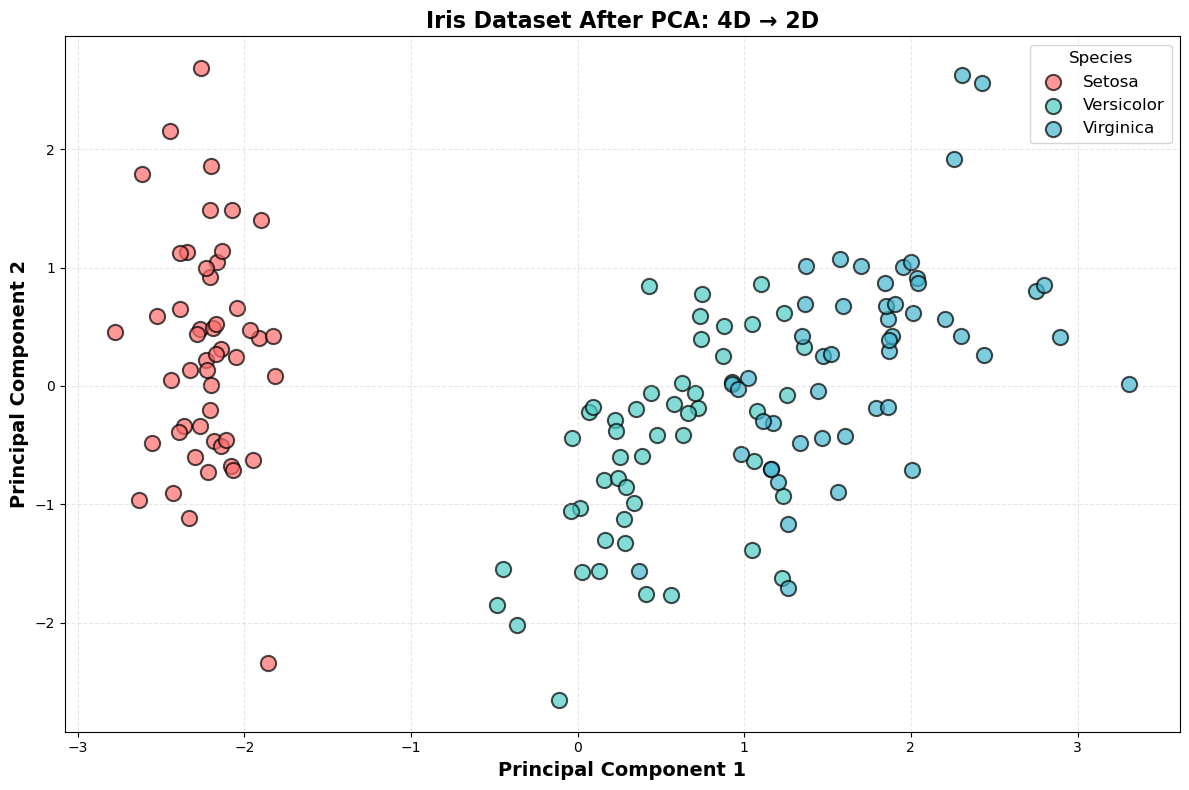


Look! The species are now clearly separated!
PCA found the best 2D view of our 4D data!


In [62]:
# Create a beautiful 2D visualization
plt.figure(figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for species_id in [0, 1, 2]:
    mask = y == species_id
    plt.scatter(
        X_pca[mask, 0],  # PC1
        X_pca[mask, 1],  # PC2
        c=colors[species_id],
        label=species_names[species_id].capitalize(),
        s=120,
        alpha=0.7,
        edgecolors='black',
        linewidth=1.5
    )

plt.xlabel('Principal Component 1', fontsize=14, fontweight='bold')
plt.ylabel('Principal Component 2', fontsize=14, fontweight='bold')
plt.title('Iris Dataset After PCA: 4D → 2D', fontsize=16, fontweight='bold')
plt.legend(title='Species', fontsize=12, title_fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nLook! The species are now clearly separated!")
print("PCA found the best 2D view of our 4D data!")

---

# STEP 9: Compare - Before and After PCA

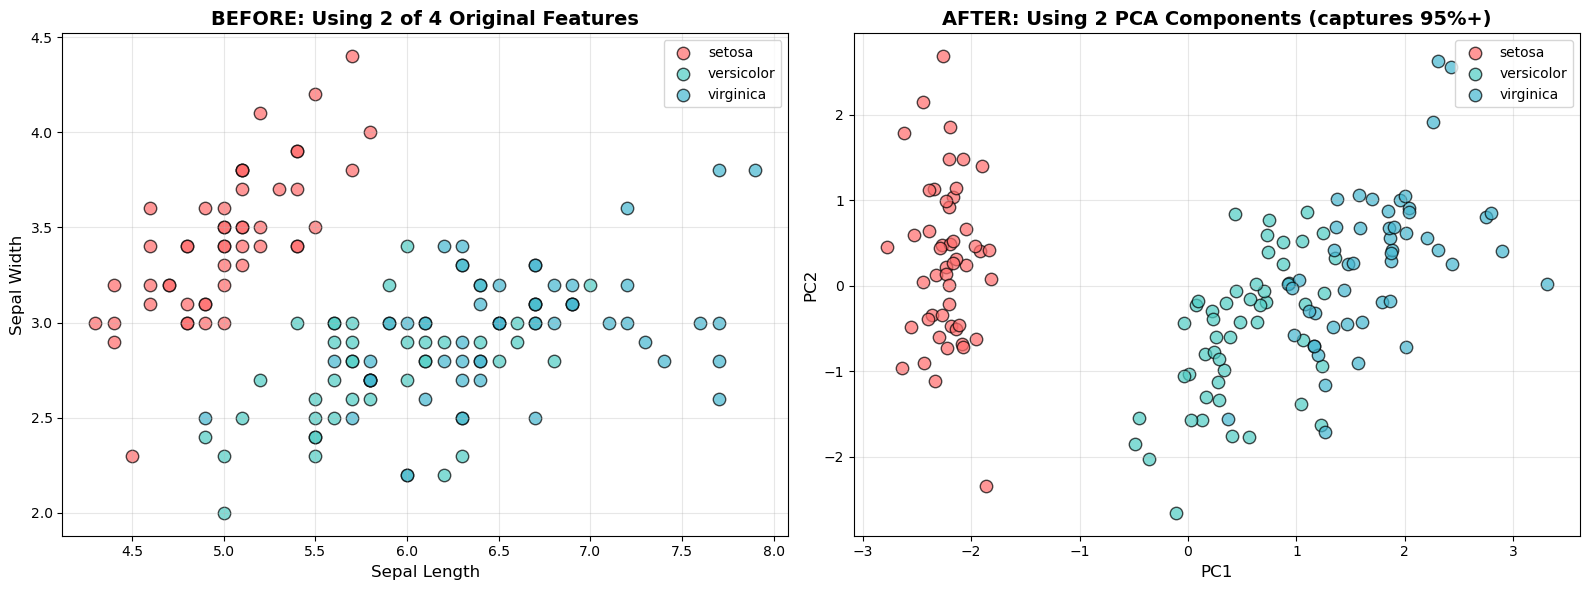


The PCA version shows MUCH better separation!
This is because PCA uses information from ALL 4 features.


In [69]:
# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Plot 1: Original features (only 2 of 4)
for species_id in [0, 1, 2]:
    mask = y == species_id
    axes[0].scatter(X[mask, 0], X[mask, 1], c=colors[species_id],
                   label=species_names[species_id], s=80, alpha=0.7, edgecolors='black')

axes[0].set_xlabel('Sepal Length', fontsize=12)
axes[0].set_ylabel('Sepal Width', fontsize=12)
axes[0].set_title('BEFORE: Using 2 of 4 Original Features', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: PCA features
for species_id in [0, 1, 2]:
    mask = y == species_id
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[species_id],
                   label=species_names[species_id], s=80, alpha=0.7, edgecolors='black')

axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('AFTER: Using 2 PCA Components (captures 95%+)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nThe PCA version shows MUCH better separation!")
print("This is because PCA uses information from ALL 4 features.")

---

# STEP 10: Understanding What PCA Found

Let's see what the principal components actually mean.

In [72]:
# Get the component loadings
# These show how much each original feature contributes to each PC
loadings = pca_2d.components_

print("Component Loadings:")
print("="*60)
print(f"{'Feature':<20} {'PC1':>10} {'PC2':>10}")
print("-"*60)

for i, name in enumerate(feature_names):
    print(f"{name:<20} {loadings[0, i]:>10.3f} {loadings[1, i]:>10.3f}")

Component Loadings:
Feature                     PC1        PC2
------------------------------------------------------------
sepal length (cm)         0.521      0.377
sepal width (cm)         -0.269      0.923
petal length (cm)         0.580      0.024
petal width (cm)          0.565      0.067


In [74]:
# Interpret the results
print("\n" + "="*50)
print("INTERPRETATION")
print("="*50)

print("\nPC1 (captures 72.8% variance):")
print("  - High positive loading for petal length and width")
print("  - This means PC1 mainly captures 'flower size'")
print("  - Larger flowers have higher PC1 values")

print("\nPC2 (captures 23% variance):")
print("  - High positive loading for sepal width")
print("  - Negative loading for sepal length")
print("  - This captures 'sepal shape' (wide vs long)")


INTERPRETATION

PC1 (captures 72.8% variance):
  - High positive loading for petal length and width
  - This means PC1 mainly captures 'flower size'
  - Larger flowers have higher PC1 values

PC2 (captures 23% variance):
  - High positive loading for sepal width
  - Negative loading for sepal length
  - This captures 'sepal shape' (wide vs long)


---

# STEP 11: Using PCA with Machine Learning

Let's see if a classifier works well on PCA-reduced data!

In [79]:
# Import classifier and tools
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

print("Classifier tools loaded!")

Classifier tools loaded!


In [81]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 105 samples
Test set: 45 samples


In [83]:
# Train on ORIGINAL data (4 features)
knn_original = KNeighborsClassifier(n_neighbors=5)

start = time.time()
knn_original.fit(X_train, y_train)
time_original = time.time() - start

y_pred_original = knn_original.predict(X_test)
accuracy_original = accuracy_score(y_test, y_pred_original)

print(f"Original (4 features): Accuracy = {accuracy_original*100:.1f}%")

Original (4 features): Accuracy = 100.0%


In [85]:
# Apply PCA to training and test data
pca_ml = PCA(n_components=2)
X_train_pca = pca_ml.fit_transform(X_train)
X_test_pca = pca_ml.transform(X_test)  # Use transform only, not fit_transform!

print(f"PCA training set: {X_train_pca.shape}")
print(f"PCA test set: {X_test_pca.shape}")

PCA training set: (105, 2)
PCA test set: (45, 2)


In [87]:
# Train on PCA data (2 features)
knn_pca = KNeighborsClassifier(n_neighbors=5)

start = time.time()
knn_pca.fit(X_train_pca, y_train)
time_pca = time.time() - start

y_pred_pca = knn_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"PCA (2 features): Accuracy = {accuracy_pca*100:.1f}%")

PCA (2 features): Accuracy = 95.6%


In [89]:
# Compare results
print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(f"\n{'Method':<20} {'Features':<10} {'Accuracy':<10}")
print("-"*50)
print(f"{'Original':<20} {4:<10} {accuracy_original*100:.1f}%")
print(f"{'PCA Reduced':<20} {2:<10} {accuracy_pca*100:.1f}%")

print("\n" + "="*50)
print("RESULT: PCA reduced features by 50% with similar accuracy!")
print("="*50)


COMPARISON

Method               Features   Accuracy  
--------------------------------------------------
Original             4          100.0%
PCA Reduced          2          95.6%

RESULT: PCA reduced features by 50% with similar accuracy!


---

# STEP 12: Final Summary

Let's create a summary table.

In [92]:
print("\n" + "="*60)
print("              PCA WORKSHOP SUMMARY")
print("="*60)

print("\n📊 ORIGINAL DATA:")
print(f"   • 150 samples")
print(f"   • 4 features (dimensions)")
print(f"   • Cannot visualize directly")

print("\n🔄 AFTER PCA:")
print(f"   • 150 samples (same)")
print(f"   • 2 principal components")
print(f"   • Captures 95.8% of information")
print(f"   • Easy to visualize in 2D!")

print("\n📈 KEY METRICS:")
print(f"   • PC1 explains: 72.8%")
print(f"   • PC2 explains: 23.0%")
print(f"   • Combined: 95.8%")

print("\n✅ BENEFITS:")
print(f"   • Reduced dimensions by 50%")
print(f"   • Clear visualization")
print(f"   • Similar ML accuracy")

print("\n" + "="*60)


              PCA WORKSHOP SUMMARY

📊 ORIGINAL DATA:
   • 150 samples
   • 4 features (dimensions)
   • Cannot visualize directly

🔄 AFTER PCA:
   • 150 samples (same)
   • 2 principal components
   • Captures 95.8% of information
   • Easy to visualize in 2D!

📈 KEY METRICS:
   • PC1 explains: 72.8%
   • PC2 explains: 23.0%
   • Combined: 95.8%

✅ BENEFITS:
   • Reduced dimensions by 50%
   • Clear visualization
   • Similar ML accuracy



---

# Exercises: Try It Yourself!

### Exercise 1: Keep Only PC1
Reduce to just 1 component. How much variance does it capture? Can you still separate species?

### Exercise 2: Digits Dataset
Load `from sklearn.datasets import load_digits` - this has 64 features! How many PCA components do you need for 95% variance?

### Exercise 3: Without Scaling
Try PCA without StandardScaler. Does it change the results?

### Exercise 4: 3D Visualization
Use 3 components and create a 3D plot using `from mpl_toolkits.mplot3d import Axes3D`

In [95]:
# Space for your experiments!
# Try the exercises here

print("Write your experiment code in this cell!")

Write your experiment code in this cell!


---

# 🎉 Congratulations!

You have completed the PCA Workshop!

**You now know how to:**
- ✅ Understand why PCA is useful
- ✅ Scale data before PCA
- ✅ Apply PCA using sklearn
- ✅ Analyze explained variance
- ✅ Visualize high-dimensional data in 2D
- ✅ Use PCA-reduced data in ML models